<div align="center">

# **EN3150 — Assignment 01**






<br><br>

## **Gunawardena H.A.**

### **230219K**

<br><br>



<br><br><br>

**05/08/2026**

</div>

<div style="page-break-after: always;"></div>

# Question 1 - Data Preprocessing and Dealing with Skewness
## 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def generate_features(n_samples=1000, student_id=230219):
    np.random.seed(student_id % 1000)

    # Feature 1: Normally distributed data
    feature_1 = np.random.normal(
        loc=50,
        scale=15,
        size=n_samples
    )

    # Feature 2: Exponentially distributed data (highly skewed)
    feature_2 = np.random.exponential(
        scale=2.0,
        size=n_samples
    )

    # Introduce a few extreme artificial outliers to Feature 2
    feature_2[np.random.choice(n_samples, 5, replace=False)] = \
        np.random.uniform(50, 100, 5)

    return feature_1, feature_2


student_id = 230219

f1, f2 = generate_features(student_id=student_id)





## 2.

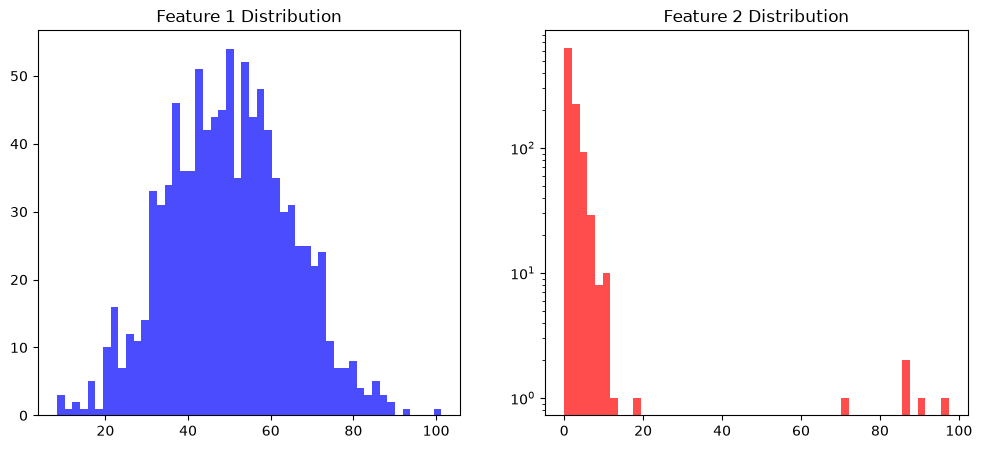

In [2]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(f1, bins=50, color='blue', alpha=0.7)
plt.title("Feature 1 Distribution")

plt.subplot(1, 2, 2)
plt.hist(f2, bins=50, color='red', alpha=0.7)
plt.yscale('log')  # Use logarithmic scale for better visibility of skewed data
plt.title("Feature 2 Distribution")

plt.show()

## 3.

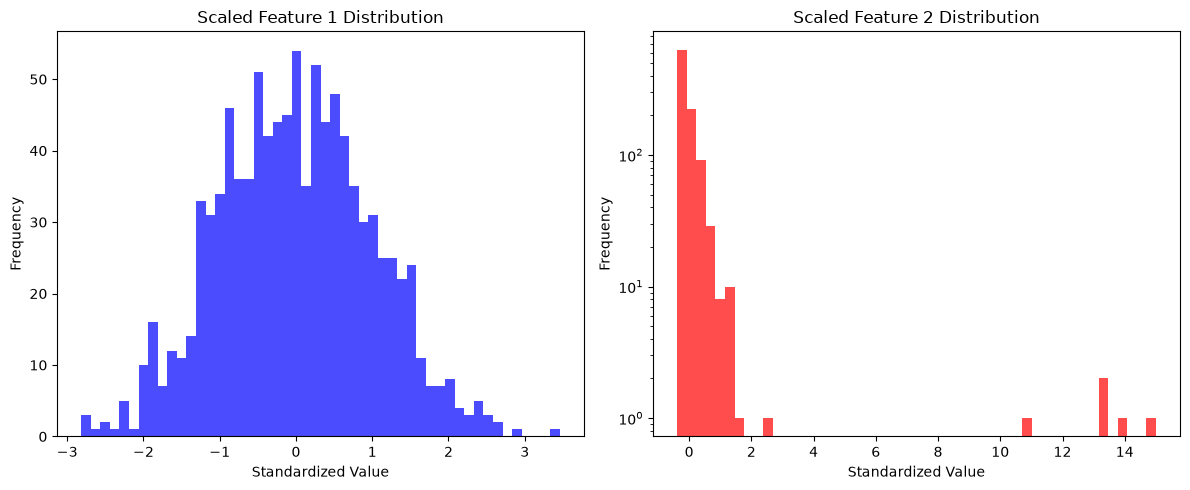

In [3]:
# Apply standard scaling 
f1_scaled = (f1 - np.mean(f1)) / np.std(f1)
f2_scaled = (f2 - np.mean(f2)) / np.std(f2)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(f1_scaled, bins=50, color='blue', alpha=0.7)
plt.title("Scaled Feature 1 Distribution")
plt.xlabel("Standardized Value")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(f2_scaled, bins=50, color='red', alpha=0.7)
plt.yscale('log')  # Use logarithmic scale for better visibility of skewed data
plt.title("Scaled Feature 2 Distribution")
plt.xlabel("Standardized Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


## 4.

As seen in the above histograms, the standard scaling has not effectively normalized the highly skewed data with extreme outiers. Standard scaling transforms each observation $(x_i)$ according to

$$
z_i = \frac{x_i-\mu}{\sigma},
$$

where $\mu$ and $\sigma$ are the mean and standard deviation of the feature, respectively.
This shifts the distribution to have a mean of approximately 0 and a standard deviation of 1. Since it is a linear transformation, it doesnt actually change the skewness of the distribution. Therefore feature 2 still remains highly right-skewed. Additionally both $\mu$ and $\sigma$ are influenced by the outliers resulting in the outliers to remain far from the centre. In conclusion the scaling did not remove the skewness or have an effect on the extreme outliers.


## 5.

A logarithmic transformation was applied to Feature 2 before standard scaling using

$$
x_i' = \log(1+x_i).
$$

This transformation compresses large positive values more strongly than small values. Therefore, the long right tail and the influence of the extreme outliers are reduced.

The transformed feature is then standardized using

$$
z_i = \frac{x_i' - \mu'}{\sigma'},
$$

where $\mu'$ and $\sigma'$ are the mean and standard deviation of the log-transformed feature.

This approach is more effective because the logarithmic transformation compresses the large positive values and reduces the skewness. the stanndard scaling then centres the data around 0. Therefore the final distribution is more balanced and is more effective for exponentially distributed data.


In [4]:
# Apply logarithmic transformation to Feature 2
f2_log = np.log1p(f2)

# Apply standard scaling after the transformation
f2_log_scaled = (f2_log - np.mean(f2_log)) / np.std(f2_log)

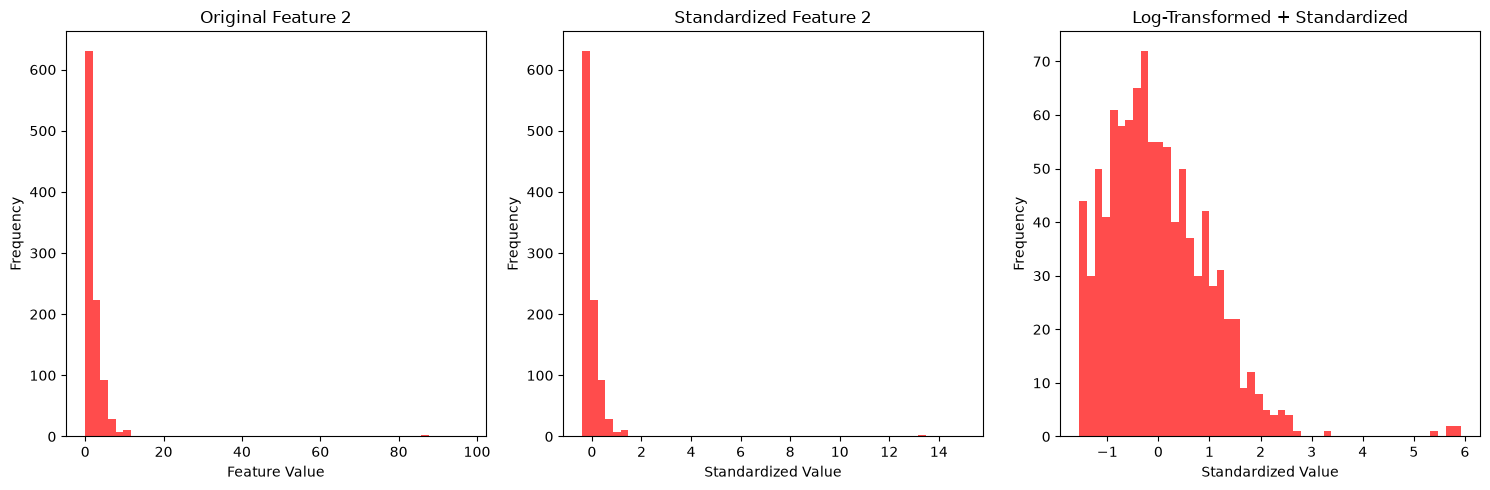

In [5]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(f2, bins=50, color='red', alpha=0.7)
plt.title("Original Feature 2")
plt.xlabel("Feature Value")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
plt.hist(f2_scaled, bins=50, color='red', alpha=0.7)
plt.title("Standardized Feature 2")
plt.xlabel("Standardized Value")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
plt.hist(f2_log_scaled, bins=50, color='red', alpha=0.7)
plt.title("Log-Transformed + Standardized")
plt.xlabel("Standardized Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Question 2 - Linear Regression and Regularization

## 1.

In [6]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

# Load the diabetes dataset
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

# Split the dataset: 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 353
Testing samples: 89


## 2.

In [8]:
from sklearn.linear_model import LinearRegression

# Train the OLS linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Generate predictions for the test set
y_pred = lr_model.predict(X_test)



The linear regression model is evaluated using the following metrics:

**Residual Standard Error (RSE)**

$$
\mathrm{RSE}
=
\sqrt{
\frac{
\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
}{
n-p-1
}
}
$$

**Mean Squared Error (MSE)**

$$
\mathrm{MSE}
=
\frac{1}{n}
\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

**Coefficient of Determination ($R^2$)**

$$
R^2
=
1-
\frac{
\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
}{
\sum_{i=1}^{n}(y_i-\bar{y})^2
}
$$

In [9]:
import numpy as np

from sklearn.metrics import mean_squared_error, r2_score

# Number of test observations and predictors
n = len(y_test)
p = X_test.shape[1]

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

rss = np.sum((y_test - y_pred) ** 2)
rse = np.sqrt(rss / (n - p - 1))

print(f"Residual Standard Error (RSE): {rse:.4f}")
print(f"Mean Squared Error (MSE):      {mse:.4f}")
print(f"R-squared (R²):                {r2:.4f}")

Residual Standard Error (RSE): 57.5256
Mean Squared Error (MSE):      2900.1936
R-squared (R²):                0.4526


## 3.

The ridge regression models are trained with $\lambda \in \{0.1,1,10\}$.


In [10]:
from sklearn.linear_model import Ridge

lambda_values = [0.1, 1, 10]

ridge_models = {}

for lam in lambda_values:
    model = Ridge(alpha=lam)
    model.fit(X_train, y_train)
    ridge_models[lam] = model

## 4.

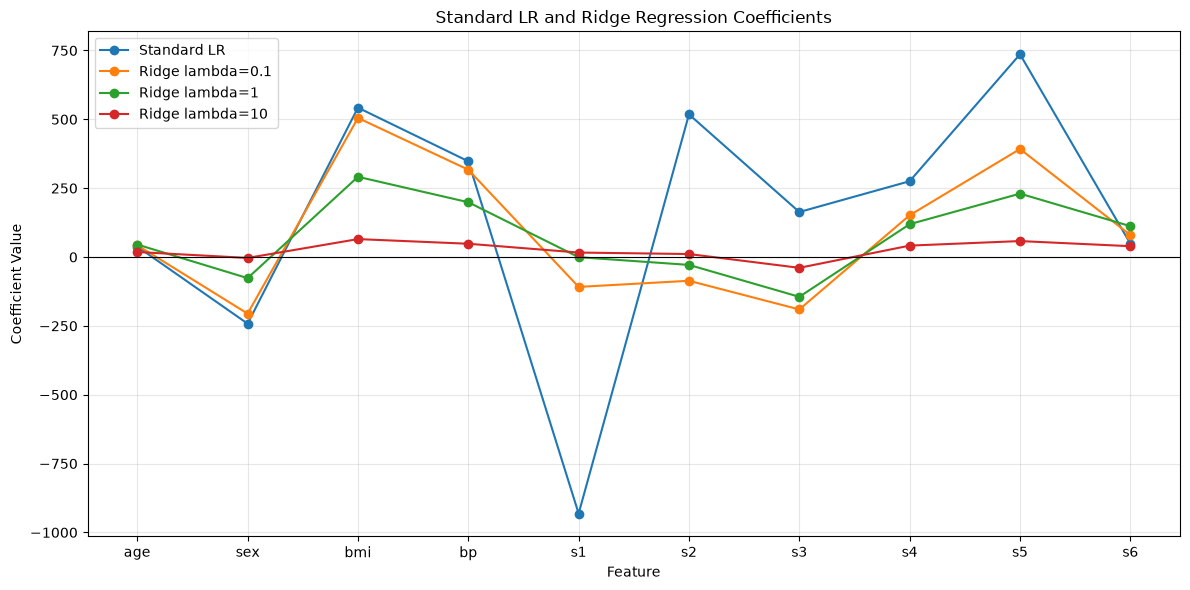

In [11]:
feature_names = diabetes.feature_names

plt.figure(figsize=(12, 6))

# OLS coefficients
plt.plot(
    feature_names,
    lr_model.coef_,
    marker='o',
    label='Standard LR'
)

# Ridge coefficients
for lam, model in ridge_models.items():
    plt.plot(
        feature_names,
        model.coef_,
        marker='o',
        label=f'Ridge lambda={lam}'
    )

plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.title("Standard LR and Ridge Regression Coefficients")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5.

The Ridge Regression loss function is

$$
L(w)
=
\frac{1}{N}
\sum_{i=1}^{N}
(y_i-w^Tx_i)^2
+
\lambda
\sum_{j=1}^{d}w_j^2.
$$

As $\lambda$ increases, the contribution of the regularization term

$$
\lambda\sum_{j=1}^{d}w_j^2
$$

becomes more significant. Therefore, large values of the model weights result in a greater penalty, which causes their magnitudes to decrease. Then, as $\lambda \rightarrow \infty,$ the estimated coefficient values approach zero:

$$
w_j \rightarrow 0,
\qquad j=1,\ldots,d.
$$

This property makes Ridge Regression more robust when the features are highly correlated. In standard Linear Regression, highly correlated features can result in unstable coefficient estimates, where small changes in the training data may produce large changes in the estimated weights. Ridge Regression restricts these large coefficient values through the $L_2$ penalty.

As a result of this, correlated features are prevented from producing very large and unstable weights. Overall ridge Regression reduces the variance of the estimated coefficients and produces a more stable model.



# Question 3 - Robust regression and Huber Loss

## 1.

The Mean Squared Error (MSE) is defined as

$$
\mathrm{MSE}
=
\frac{1}{N}
\sum_{i=1}^{N}
(y_i-\hat{y}_i)^2.
$$

In [12]:
# Given dataset
x = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
y = np.array([2.5, 4.1, 6.2, 8.0, 35.0, 12.1])

# Model predictions
y_pred_A = 3.8 * x - 2.0
y_pred_B = 2.0 * x + 0.2

# Residuals
residuals_A = y - y_pred_A
residuals_B = y - y_pred_B

# Mean Squared Error
mse_A = np.mean(residuals_A ** 2)
mse_B = np.mean(residuals_B ** 2)

print("Model A predictions:", y_pred_A)
print("Model A residuals:", residuals_A)

print("\nModel B predictions:", y_pred_B)
print("Model B residuals:", residuals_B)

print(f"\nMSE of Model A: {mse_A:.4f}")
print(f"MSE of Model B: {mse_B:.4f}")

Model A predictions: [ 1.8  5.6  9.4 13.2 17.  20.8]
Model A residuals: [ 0.7 -1.5 -3.2 -5.2 18.  -8.7]

Model B predictions: [ 2.2  4.2  6.2  8.2 10.2 12.2]
Model B residuals: [ 0.3 -0.1  0.  -0.2 24.8 -0.1]

MSE of Model A: 73.2850
MSE of Model B: 102.5317


The calculated Mean Squared Errors are

$$
{\mathrm{MSE}_A = 73.285}
$$

and

$$
{\mathrm{MSE}_B = 102.532}.
$$

Therefore, Model A has the lower MSE.


## 2.

In [13]:
delta = 3.0

def huber_loss(y, y_pred, delta):
    residual = y - y_pred
    abs_residual = np.abs(residual)

    return np.where(
        abs_residual <= delta,
        0.5 * residual ** 2,
        delta * abs_residual - 0.5 * delta ** 2
    )

# Huber loss for each data point
huber_A = huber_loss(y, y_pred_A, delta)
huber_B = huber_loss(y, y_pred_B, delta)

# Average Huber loss
avg_huber_A = np.mean(huber_A)
avg_huber_B = np.mean(huber_B)

print("Huber losses for Model A:", huber_A)
print("Huber losses for Model B:", huber_B)

print(f"\nAverage Huber Loss of Model A: {avg_huber_A:.4f}")
print(f"Average Huber Loss of Model B: {avg_huber_B:.4f}")

Huber losses for Model A: [ 0.245  1.125  5.1   11.1   49.5   21.6  ]
Huber losses for Model B: [4.50e-02 5.00e-03 0.00e+00 2.00e-02 6.99e+01 5.00e-03]

Average Huber Loss of Model A: 14.7783
Average Huber Loss of Model B: 11.6625


The average Huber losses for $\delta=3.0$ are

$$
\overline{L}_A = 14.7783
$$

and

$$
\overline{L}_B = 11.6625.
$$

Therefore, Model B performs better under the Huber Loss, since it has the lower average loss.


## 3.

For the outlier at

$$
x_5 = 5.0,\qquad y_5 = 35.0,
$$

the two models produce

$$
\hat{y}_{A,5} = 3.8(5)-2.0 = 17.0
$$

and

$$
\hat{y}_{B,5} = 2.0(5)+0.2 = 10.2.
$$

Therefore, their absolute residuals are

$$
|y_5-\hat{y}_{A,5}| = |35.0-17.0| = 18.0
$$

and

$$
|y_5-\hat{y}_{B,5}| = |35.0-10.2| = 24.8.
$$

When calculating the squared-error term used in MSE, the outlier provides

$$
18.0^2 = 324
$$

for Model A and

$$
24.8^2 = 615.04
$$

for Model B.

This results in the penalty increasing quadratically with the residual magnitude, causing the outlier to greatly influence the overall MSE.

For the Huber loss with $\delta=3.0$, both residuals satisfy

$$
|y-\hat{y}|>\delta.
$$

Therefore, the Huber loss equation used is,

$$
L_\delta(y,\hat{y})
=
\delta|y-\hat{y}|-\frac{1}{2}\delta^2.
$$

For Model A,

$$
L_A
=
3(18.0)-\frac{1}{2}(3)^2 = 
49.5,
$$

for Model B,

$$
L_B
=
3(24.8)-\frac{1}{2}(3)^2 = 
69.9.
$$

Hence, the outlier contributions are reduced from

$$
324 \rightarrow 49.5
$$

for Model A and

$$
615.04 \rightarrow 69.9
$$

for Model B.

This occurs because MSE is influenced by large residuals quadratically, whereas the Huber loss changes to a linear penalty once the residual magnitude exceeds $\delta$. As a result, the influence of the severe outlier is limited, allowing the model that better follows the majority of the data to be preferred.

This is clearly seen in the calculated results: MSE selects Model A,

$$
\mathrm{MSE}_A = 73.285
<
\mathrm{MSE}_B = 102.532,
$$

but the average Huber loss selects Model B,

$$
\overline{L}_B = 11.6625
<
\overline{L}_A = 14.7783.
$$

Therefore, the Huber loss is more robust to the outlier and identifies Model B as the better representation of the underlying trend.



# Question 4 - Loss Functions Comparison



## 1.

The Binary Cross Entropy loss is

$$
\mathrm{BCE}
=
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right].
$$

When the true label is $y_i=1,$ the second term becomes zero and the loss reduces to  $$-\log(\hat{y}_i).$$
Therefore, predictions close to $\hat{y}_i=1$ produce a small loss, while predictions close to $\hat{y}_i=0$ produce a very large loss.

When the true label is $y_i=0,$ the first term becomes zero and the loss reduces to $$-\log(1-\hat{y}_i).$$
Therefore, predictions close to $\hat{y}_i=0$ produce a small loss, while predictions close to $\hat{y}_i=1$ produce a very large loss.

This results in the logarithmic terms strongly penalizing any predictions that gave an incorrect assessment a higher probability .


## 2.



In [14]:
y = 1
y_hat = 0.01

mae = abs(y - y_hat)
bce = -(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

print(f"MAE: {mae:.4f}")
print(f"BCE: {bce:.4f}")

MAE: 0.9900
BCE: 4.6052


For $y=1$ and $\hat{y}=0.01$,

$$
\mathrm{MAE}=0.99
$$


$$
\mathrm{BCE}=4.6052.
$$


## 3.

The calculated values show that BCE penalizes an incorrect and highly confident probability prediction much more strongly than MAE.

For the positive sample with

$$
y=1,\qquad \hat{y}=0.01,
$$

MAE produces 0.99, whereas BCE produces 4.6052.


The MAE penalty changes linearly with the prediction error, while BCE increases sharply when the predicted probability assigned to the true class approaches zero. This makes BCE more sensitive to confident incorrect predictions.

For binary classifications, this is better because the model should receive a strong penalty when it assigns very low probability to the correct class. At the same time, BCE gives a small loss when the predicted probability is close to the correct label.

Therefore, BCE is more suitable than MAE for training binary probability models because it directly shows the quality of the predicted probabilities and strongly penalizes incorrect classifications.
